# 📈 Sales Forecast Dashboard

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/sales-forecast/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/sales-forecast/demo.ipynb)

> **Pain point:** *Forecasts live in someone's spreadsheet.*

A forecast buried in a tab nobody can reproduce isn't a forecast — it's a guess with a chart. This takes a plain sales history and produces a forward forecast with a confidence band **and** an honest backtest (MAPE), so the number comes with a trust level attached.

**What this notebook covers**
1. The core logic — engine, seasonality, backtest
2. A sample sales history (36 months, trend + seasonality)
3. Forecasting 12 months ahead
4. How accurate is it? (backtest MAPE)
5. The forecast chart with a confidence band


## Step 1 — The core logic

The engine is **Holt-Winters exponential smoothing** (statsmodels) — light, reliable, and always installed. It detects the date/value columns, infers the frequency, adds seasonality when there's enough history, and backtests on a held-out tail. If the optional `prophet` package is present you can pass `engine='prophet'` instead. No API keys.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from forecast import forecast_sales, prepare_series, sample_sales

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Core logic loaded.')

Core logic loaded.


## Step 2 — A sample sales history

`sample_sales()` builds a deterministic 36-month series (seed=42) with a rising trend, yearly seasonality, and noise — exactly the shape a real monthly revenue series has.

In [2]:
df = sample_sales()
print(f'{len(df)} months of history')
df.head()

36 months of history


,date,sales
0,2022-01-01,11082.83
1,2022-02-01,11275.43
2,2022-03-01,12899.12
3,2022-04-01,13024.34
4,2022-05-01,10818.22


The tool figures out which column is the date and which is the value, then infers the frequency on its own:

In [3]:
series, freq = prepare_series(df)
print('Inferred frequency:', freq)
series.tail(3)

Inferred frequency: MS


,ds,y
33,2024-10-01,14971.74
34,2024-11-01,16740.74
35,2024-12-01,18256.81


## Step 3 — Forecast 12 months ahead

One call returns the forecast plus a 95% confidence band.

In [4]:
res = forecast_sales(df, periods=12)
print('Engine:', res.engine, '| seasonal periods:', res.seasonal_periods)
res.forecast

Engine: holt-winters | seasonal periods: 12


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,19049.12,18364.78,19733.45
1,2025-02-01,20007.16,19322.83,20691.50
2,2025-03-01,20959.58,20275.25,21643.92
3,2025-04-01,20710.08,20025.75,21394.42
4,2025-05-01,19915.69,19231.36,20600.03
5,2025-06-01,19015.24,18330.91,19699.58
6,2025-07-01,19210.21,18525.88,19894.55
7,2025-08-01,17866.73,17182.39,18551.06
8,2025-09-01,17769.10,17084.76,18453.43
9,2025-10-01,17871.21,17186.87,18555.54


## Step 4 — How accurate is it?

The backtest trains on everything *except* the last stretch, predicts it, and measures the error (MAPE) against what actually happened. That's the honesty check a spreadsheet forecast never gives you.

In [5]:
m = res.metrics
print(f"Backtest MAPE: {m['mape_pct']}%")
print(f"History avg:   {m['history_mean']:,.0f}")
print(f"Forecast avg:  {m['forecast_mean']:,.0f}")

Backtest MAPE: 2.61%
History avg:   13,894
Forecast avg:  19,415


## Step 5 — The forecast chart

History, forecast, and the confidence band in one view — the slide a sales leader actually wants.

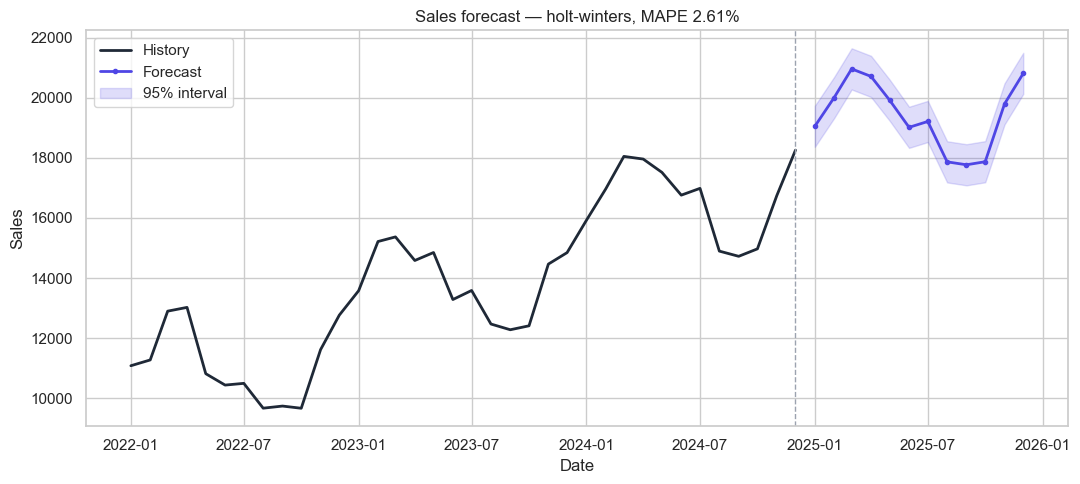

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
hist = res.history
ax.plot(hist['ds'], hist['y'], color='#1F2937', linewidth=2, label='History')
ax.plot(res.forecast['ds'], res.forecast['yhat'], color='#4F46E5',
        linewidth=2, marker='o', markersize=3, label='Forecast')
ax.fill_between(res.forecast['ds'], res.forecast['yhat_lower'],
                res.forecast['yhat_upper'], color='#4F46E5', alpha=0.18,
                label='95% interval')
ax.axvline(hist['ds'].iloc[-1], color='#9CA3AF', linestyle='--', linewidth=1)
ax.set_title(f"Sales forecast — {res.engine}, MAPE {m['mape_pct']}%")
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

From a flat sales table to a reproducible forecast with a confidence band and a MAPE you can defend. Re-run it when the data updates and the forecast updates with it — no more stale spreadsheet tab.

## 🔧 Try your own

Uncomment and point it at your own sales export:

In [7]:
# import pandas as pd
# my_df = pd.read_csv('your_sales.csv')         # date column + value column
# res = forecast_sales(my_df, periods=6)        # forecast 6 periods
# print('MAPE:', res.metrics['mape_pct'])
# res.forecast
# # If you've installed prophet:
# # res = forecast_sales(my_df, periods=6, engine='prophet')

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 27 of the 60-day FDE portfolio.

**Run the Streamlit version:**
```bash
pip install -r requirements.txt
streamlit run app.py
```